# Session 2 Introduction: Maya's Adaptive Engine at Lindenfield

Three months after Maya Chen signed off on the Balanced allocation at __Lindenfield Wealth Partners__, Lou stops by her desk Thursday afternoon. The book had stayed untouched since intake. A five-week drawdown in August cost it twenty-one percent, tripped the firm's drawdown review threshold, and put the account on the risk committee's agenda for next Thursday. Maya followed every policy on the page: firm procedure holds Balanced-archetype books static between quarterly reviews, and August was still six weeks from the next review. __Bud Fox__, who built the AI intake tool, answers for the design; Maya answers for the process and needs a credible fix for Thursday. The Session 1 scorecard she built had called this outcome rare but not impossible (which is not a defense for the risk committee).

The following morning Maya walks to the research floor looking for anyone thinking about regime-aware allocation. She finds __Dr. Amara Okafor__, Head of Quantitative Research, who has kept a utility-based framework on the internal roadmap for two years. Amara's pitch is surgical: minimum-variance hides its preferences in a covariance inverse no committee can read, needs a solver that can fail silently, and cannot couple to a regime signal without being re-solved from scratch. A utility-based allocator replaces all three with a written preference vector, a closed-form optimum, and a scalar signal that reshapes preferences in place.

__Scenario__: Lou's advice is plain: do not walk into the committee with a derivation, walk in with a number. He will be in the room Thursday, but Maya will do the talking. She needs one number: fifth-percentile terminal wealth on the worst quarter of market paths, static book versus Amara's engine. That is what Amara's framework, wrapped in Lindenfield's existing trigger rules, has to produce on the path her book just lived through.

By the end of the session Maya will have three answers to bring to the committee. First, how does Amara's engine _know_ the regime has shifted, and how fast does that signal update? Second, how does the engine _translate_ that signal into new positions without trusting a noisy covariance matrix? Third, what _rules_ force the engine to stop trading or de-risk when things go wrong, and who signs off on those rules?

___


In [1]:
include("Include.jl"); # Load packages and helper functions. Activates the local Julia environment.

## The Same Book, A Worse Path
Consider a single hybrid Single Index Model (SIM) forward path drawn from the same market generator Session 1 used. The black line below is the Session 1 minimum-variance allocation, held unchanged for the year. The orange line is the Session 2 Cobb-Douglas rebalancing engine running on the same path, with a drawdown circuit breaker and a turnover cap. 

The engine is not clairvoyant; it only sees prices as they arrive. But it can rebalance, and the drawdown trigger forces a de-risk action when the portfolio falls past a preset threshold. Watch where the two lines diverge.

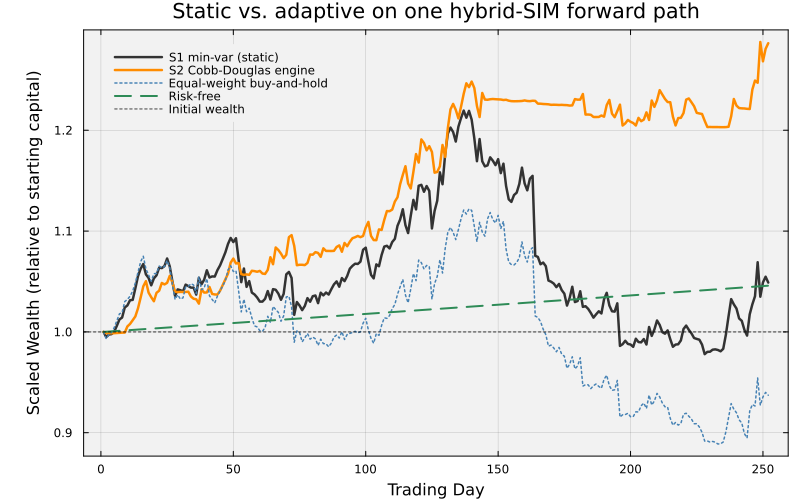

In [2]:
let

    # --- Load the cached single-path scorecard run ---
    scd = load_results(joinpath(_PATH_TO_DATA, "session2-scorecard.jld2"));
    mv  = scd["minvar_wealth"];
    eng = scd["engine_wealth"];
    eq  = scd["equalweight_wealth"];
    rf  = scd["riskfree_wealth"];

    # --- Align lengths (engine may carry an extra initialization day) ---
    T    = min(length(mv), length(eng), length(eq), length(rf));
    days = 1:T;
    sw(x) = x[1:T] ./ x[1];

    pl = plot(days, sw(mv);
        lw = 2.5, c = :gray20, label = "S1 min-var (static)",
        xlabel = "Trading Day", ylabel = "Scaled Wealth (relative to starting capital)",
        size = (800, 500), fontsize = 14, left_margin = 8Plots.mm);
    plot!(pl, days, sw(eng);
        lw = 2.5, c = :darkorange, label = "S2 Cobb-Douglas engine");
    plot!(pl, days, sw(eq);
        lw = 1.5, ls = :dot, c = :steelblue, label = "Equal-weight buy-and-hold");
    plot!(pl, days, sw(rf);
        lw = 2, ls = :dash, c = :seagreen, label = "Risk-free");
    hline!(pl, [1.0]; lw = 1.5, ls = :dot, c = :black, alpha = 0.5, label = "Initial wealth");
    plot!(pl, bg = "gray95", background_color_outside = "white",
        framestyle = :box, fg_legend = :transparent, legend = :topleft);
    title!(pl, "Static vs. adaptive on one hybrid-SIM forward path");
    display(pl);
end;

One path is a story, not evidence. The figure below summarizes both strategies across five thousand independent hybrid-SIM futures restricted to the _bear subset_, the quarter of paths where the market realized the lowest annual return. 

The vertical lines mark the fifth-percentile terminal net present value (NPV, the worst-case present value) on each distribution. That fifth-percentile number is what an audit committee asks for first: given the worst twenty-five percent of markets, how much value is left at the end of the year?

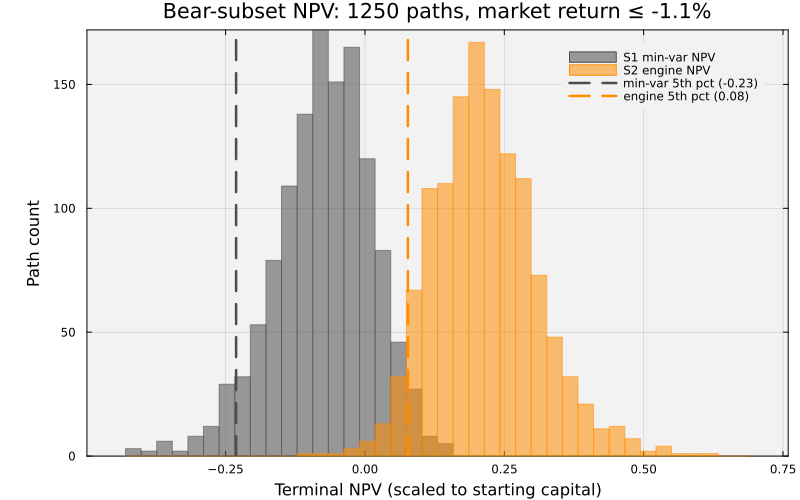

In [3]:
let

    # --- Load the 5,000-path stress test ---
    st   = load_results(joinpath(_PATH_TO_DATA, "stress-test-engine.jld2"));
    mr   = st["market_return"];
    mv_n = st["mv_npv"];
    en_n = st["eng_npv"];
    B₀   = st["B₀"];

    # --- Bear subset: bottom-quartile market return ---
    bear_cut = quantile(mr, 0.25);
    bear_idx = findall(<=(bear_cut), mr);
    mv_bear  = mv_n[bear_idx] ./ B₀;
    en_bear  = en_n[bear_idx] ./ B₀;

    q5_mv  = quantile(mv_bear, 0.05);
    q5_eng = quantile(en_bear, 0.05);

    # --- Shared bin edges so the two histograms are directly comparable ---
    lo, hi = minimum(vcat(mv_bear, en_bear)), maximum(vcat(mv_bear, en_bear));
    edges  = range(lo, hi; length = 41);

    pl = histogram(mv_bear;
        bins = edges, alpha = 0.55, c = :gray30, lc = :gray30,
        label = "S1 min-var NPV",
        xlabel = "Terminal NPV (scaled to starting capital)", ylabel = "Path count",
        size = (800, 500), fontsize = 14, left_margin = 8Plots.mm);
    histogram!(pl, en_bear;
        bins = edges, alpha = 0.55, c = :darkorange, lc = :darkorange,
        label = "S2 engine NPV");
    vline!(pl, [q5_mv]; lw = 2.5, ls = :dash, c = :gray30,
        label = "min-var 5th pct ($(round(q5_mv, digits=2)))");
    vline!(pl, [q5_eng]; lw = 2.5, ls = :dash, c = :darkorange,
        label = "engine 5th pct ($(round(q5_eng, digits=2)))");
    plot!(pl, bg = "gray95", background_color_outside = "white",
        framestyle = :box, fg_legend = :transparent, legend = :topright);
    title!(pl, "Bear-subset NPV: $(length(bear_idx)) paths, market return ≤ $(round(bear_cut*100, digits=1))%");
    display(pl);
end;

## Is Maya ready for Thursday?
Amara's engine's fifth percentile is further to the right than the static book's fifth percentile on the paths that matter for the review. However, before Maya can walk in with that case, Amara's three claims still need to be made operational.

* __Claim 1, the signal__. Amara says the engine _notices_ regime change through a sentiment variable $\lambda_t$ informed by a market index and preference coefficients. The lecture defines $\lambda_t$ and shows how it feeds the preference weights that drive the allocator.
* __Claim 2, the utility function__. Amara says a Cobb-Douglas utility replaces the minimum-variance quadratic program with a closed-form optimum whose preference exponents move with $\lambda_t$. The lecture derives that closed form and exposes the single scalar lever that reshapes preferences without re-solving anything.
* __Claim 3, the trigger rules__. Amara says an allocator that trades on every flicker of $\lambda_t$ is worse than one that never trades. The lecture adds a drawdown limit, a turnover cap, and a reallocation schedule that together encode the committee's risk policy into the machine's decision loop.

Maya cannot make the case yet. The lecture that follows turns Amara's three claims into the engine that answers the committee with rules, not just a picture.
___
